In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fleck
import batman
import astropy.units  as u
import h5py
from shapely.geometry.point import Point
from shapely import affinity
from scipy.spatial.distance import pdist, squareform

In [2]:
## -- load c time axis
l = np.load('./data/lightcurves/broadband_readysave_case3.npz')
t_c = l['t']
del l

## -- load b+d time axis
l2 = np.load('../v1298tau_bd/fits/broadband/v1298tau_bd_broadband_fleck_models.npz')
t_bd = l2['t']
del l2

In [3]:
## -- initialize planet properties
planet_c = batman.TransitParams()
tc_c = 60924.269172581
planet_c.t0 = tc_c
planet_c.per = 8.2438
planet_c.rp = 0.035411202
planet_c.a = 11.45
planet_c.inc = 87.16
planet_c.ecc = 0.
planet_c.w = 90.
planet_c.u = [0.11669, 0.633]
planet_c.limb_dark = "quadratic"
planet_c.lam = 0.

planet_b = batman.TransitParams()
tc_b = 60929.002944444
planet_b.t0 = tc_b
planet_b.per = 24.1315
planet_b.rp = 0.0620
planet_b.a = 27.0
planet_b.inc = 89.0
planet_b.ecc = 0.
planet_b.w = 90.
planet_b.u = [0.0017, 0.6576]
planet_b.limb_dark = 'quadratic'
planet_b.lam = 0.

planet_d = batman.TransitParams()
tc_d = 60928.860150000
planet_d.t0 = tc_d
planet_d.per = 12.3960
planet_d.rp = 0.0435
planet_d.a = 17.27
planet_d.inc = 89.04
planet_d.ecc = 0.
planet_d.w = 90.
planet_d.u = [0.0017, 0.6576]
planet_d.limb_dark = 'quadratic'
planet_d.lam = 0.

## -- set spot properties
v1_spotradii = np.array([[0.05766],[0.07870],[0.11685],[0.26535],[0.04773],[0.180]])
v1_spotlats = np.array([[-32.25],[-30.49],[-27.36],[-18.90],[-32.284],[-27.0]])
v1_spotlons = np.array([[-46.91],[-37.71],[-12.01],[2.21],[22.49],[46.15]])
v1_contrast = 0.7031

v2_spotradii = np.array([[0.252385],[0.219142],[0.040837],[0.222790],[0.174854],[0.139416],[0.13381],[0.044505]])
v2_spotlats = np.array([[-4.307850],[-38.887935],[-29.930900],[-37.619925],[-17.588399],[-32.519730],[-20.529416],[-30.156544]])
v2_spotlons = np.array([[-18.027660],[-3.834718],[-42.13452],[-25.186742],[1.80005],[18.608737],[30.186465],[-59.730348]])
v2_contrast = 0.63925


## -- set up fleck
inc_stellar = 90*u.deg
star_v1 = fleck.Star(spot_contrast=v1_contrast, u_ld=planet_c.u, rotation_period=300.)
star_v2 = fleck.Star(spot_contrast=v2_contrast, u_ld=planet_d.u, rotation_period=300.)

In [4]:
## -- IMPORTANT NOTE !!!!
## -- plotting functions taken from fleck API (https://fleck.readthedocs.io/en/stable/_modules/fleck/core.html#Star.plot)
## -- for the purpose of adding color customization to the plot() attribute
## -- credit B. Morris and fleck appropriately if you re-use.

def circle(center, radius):
    """
    Create a shapely ellipse.

    Parameters
    ----------
    center : list
        [x, y] centroid of the ellipse
    radius : float
        Radius of the circle

    Returns
    -------
    circle : `~shapely.geometry.polygon.Polygon`
        Circular shapely object
    """
    return affinity.scale(Point(center).buffer(1),
                          xfact=radius, yfact=radius)

def ellipse(center, lengths, angle=0):
    """
    Create a shapely ellipse.

    Parameters
    ----------
    center : list
        [x, y] centroid of the ellipse
    lengths : list
        [a, b] semimajor and semiminor axes
    angle : float
        Angle in degrees to rotate the semimajor axis

    Returns
    -------
    ellipse : `~shapely.geometry.polygon.Polygon`
        Elliptical shapely object
    """
    ell = affinity.scale(Point(center).buffer(1),
                         xfact=lengths[0], yfact=lengths[1])
    ell_rotated = affinity.rotate(ell, angle=angle)
    return ell_rotated

def sort_plot_points(xy_coord, k0=0):
    """
    Iteratively identify a continuous path from the given points xy_coord,
    starting by the point indexed by k0
    """
    n = len(xy_coord)
    distance_matrix = squareform(pdist(xy_coord, metric='euclidean'))
    mask = np.ones(n, dtype='bool')
    sorted_order = np.zeros(n, dtype=int)
    indices = np.arange(n)

    i = 0
    k = k0
    while True:
        sorted_order[i] = k
        mask[k] = False

        dist_k = distance_matrix[k][mask]
        indices_k = indices[mask]

        if not len(indices_k):
            break

        # find next unused closest point
        k = indices_k[np.argmin(dist_k)]
        i += 1
    return sorted_order    

def plot(self, spot_lons, spot_lats, spot_radii, inc_stellar, time=None,
             planet=None, planet_colors=None, ax=None, time_ref=0):
        """
        Generate a plot of the stellar surface at ``time``.

        Takes the same arguments as `~fleck.Star.light_curve` with the exception
        of the singular ``time`` rather than ``times``, plus ``ax`` for
        pre-defined matplotlib axes.

        Coordinate frame is the "observer oriented" view defined in Fabrycky &
        Winn (2009) Figure 1a. The planet transits from left to right across the
        image. The dashed gray lines represent the upper and lower bounds of the
        planet's transit chord.

        Parameters
        ----------
        spot_lons : `~astropy.units.Quantity`
            Spot longitudes
        spot_lats : `~astropy.units.Quantity`
            Spot latitudes
        spot_radii : `~numpy.ndarray`
            Spot radii
        inc_stellar : `~astropy.units.Quantity`
            Stellar inclination
        time : float
            Time at which to evaluate the spot parameters
        planet : `~batman.TransitParams` or list
            Planet parameters, or list of planet parameters.
        ax : `~matplotlib.pyplot.Axes`, optional
            Predefined matplotlib axes
        time_ref : float
            Reference time used as the initial rotational phase of the star,
            such that the sub-observer point is at zero longitude at
            ``time_ref``.

        Returns
        -------
        ax : `~matplotlib.pyplot.Axes`
            Axis object.
        """
        tilted_spots = self.spherical_to_cartesian(spot_lons, spot_lats,
                                                   inc_stellar,
                                                   times=np.array([time]),
                                                   planet=planet,
                                                   time_ref=time_ref)
        spots = []

        for i in range(len(spot_lons)):
            # If the spot is visible (x > 0):
            if tilted_spots.x.value[0, i] > 0:
                spot_y = tilted_spots.y.value[0, i]
                spot_z = tilted_spots.z.value[0, i]

                # Compute the spot position and ellipsoidal shape
                r_spot = np.hypot(spot_z, spot_y)
                angle = np.arctan2(spot_z, spot_y)
                ellipse_centroid = np.array([
                    np.squeeze(spot_y),
                    np.squeeze(spot_z)
                ])

                ellipse_axes = np.array([
                    np.squeeze(spot_radii[i, 0] *
                               np.sqrt(1 - r_spot ** 2)),
                    np.squeeze(spot_radii[i, 0])
                ])

                spot = ellipse(ellipse_centroid, ellipse_axes,
                               np.degrees(angle))

                # Add the spot to our spot list
                spots.append(spot)

        if ax is None:
            ax = plt.gca()

        if hasattr(planet, "__len__"):
            # If there are multiple planets, plot their transit chord boundaries
            # for p, color in zip(planet, ["C{0:d}".format(i)
            #                              for i in range(len(planet))]):
            for p, color in zip(planet, planet_colors):
                # Calculate impact parameter
                b = (p.a * np.cos(np.radians(p.inc)) * (1 - p.ecc**2) /
                     (1 + p.ecc * np.sin(np.radians(p.w))))

                # Compute the upper and lower envelopes of the transit chord in
                # the "observer oriented" reference frame (Fabrycky & Winn 2009)
                planet_lower_extent = -b-p.rp
                planet_upper_extent = -b+p.rp

                ax.axhline(planet_lower_extent, color=color, alpha=1, ls='--')
                ax.axhline(planet_upper_extent, color=color, alpha=1, ls='--')
        elif hasattr(planet, 'a'):
            # Calculate impact parameter
            b = (planet.a * np.cos(np.radians(planet.inc)) * (1 - planet.ecc**2) /
                 (1 + planet.ecc * np.sin(np.radians(planet.w))))

            # Compute the upper and lower envelopes of the transit chord in the
            # "observer oriented" reference frame (Fabrycky & Winn 2009)
            planet_lower_extent = -b-planet.rp
            planet_upper_extent = -b+planet.rp

            # ax.axhline(planet_lower_extent, color='gray', ls='--')
            # ax.axhline(planet_upper_extent, color='gray', ls='--')
            ax.axhline(planet_lower_extent, color=planet_colors, alpha=1, ls='--')
            ax.axhline(planet_upper_extent, color=planet_colors, alpha=1, ls='--')

        # Compute the position of the rotational pole of the star
        pole_lat, pole_lon = np.array([90])*u.deg, np.array([0])*u.deg
        polar_spot = self.spherical_to_cartesian(pole_lon, pole_lat,
                                                 inc_stellar,
                                                 times=np.array([0]),
                                                 planet=planet)

        equator_lon = np.linspace(0, 2*np.pi, 50) * u.rad
        equator_lat = np.zeros(len(equator_lon)) * u.rad
        equatorial_line = self.spherical_to_cartesian(equator_lon, equator_lat,
                                                      inc_stellar,
                                                      times=np.array([time]),
                                                      planet=planet)

        # Draw the outline of the star:
        x = np.linspace(-1, 1, 1000)
        ax.plot(x, np.sqrt(1-x**2), color='k')
        ax.plot(x, -np.sqrt(1-x**2), color='k')

        # If pole is visible, mark it:
        if polar_spot.x > 0:
            ax.scatter(-polar_spot.y, polar_spot.z, color='k', marker='x')

        # Where equator is visible, mark it:
        equator_visible = equatorial_line.x > 0
        equator_xy = np.vstack([-equatorial_line.y[equator_visible],
                                equatorial_line.z[equator_visible]]).T
        sort_equator = sort_plot_points(equator_xy,
                                        k0=np.argmax(equator_xy[:, 1]))
        ax.plot(-equatorial_line.y[equator_visible][sort_equator],
                equatorial_line.z[equator_visible][sort_equator],
                ls=':', color='gray')

        ax.set(ylim=[-1.01, 1.01], xlim=[-1.01, 1.01], aspect=1)

        # Draw each starspot:
        for i in range(len(spots)):
            spot_x, spot_y = [np.array(j.tolist())
                              for j in spots[i].exterior.xy]
            ax.fill(spot_x, spot_y, alpha=1-self.spot_contrast,
                    color='k')
        return ax

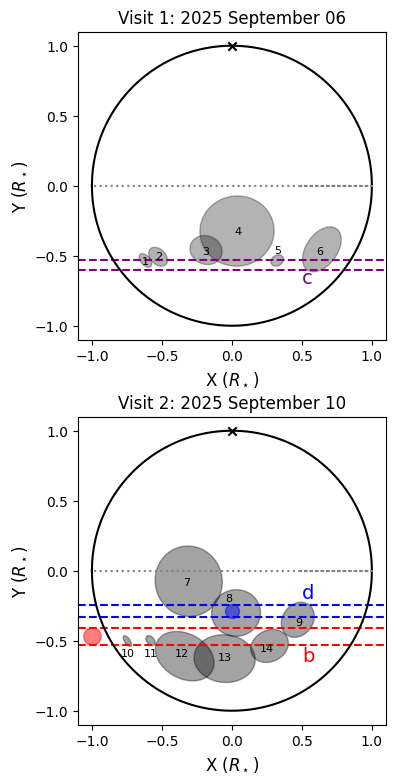

In [5]:
color_c = 'purple'
color_d = 'blue'
color_b = 'red'

fig, ax = plt.subplots(figsize=(4,9), nrows=2)
plt.subplots_adjust(hspace=0.25)
# top: visit 1
ax[0].set_title('Visit 1: 2025 September 06', fontsize=12)
ax[0] = plot(star_v1, v1_spotlons*u.deg, v1_spotlats*u.deg, v1_spotradii, inc_stellar, planet=[planet_c], planet_colors=[color_c],time=tc_c, time_ref=tc_c, ax=ax[0])
ax[0].text(0.5, -0.7, 'c', fontsize=14, c=color_c)
# bottom: visit 2
ax[1].set_title('Visit 2: 2025 September 10', fontsize=12)
ax[1] = plot(star_v2, v2_spotlons*u.deg, v2_spotlats*u.deg, v2_spotradii, inc_stellar, planet=[planet_d,planet_b], planet_colors=[color_d, color_b],time=tc_c, time_ref=tc_c, ax=ax[1])
ax[1].text(0.5, -0.2, 'd', fontsize=14, c=color_d)
ax[1].text(0.5, -0.65, 'b', fontsize=14, c=color_b)

# add spot labels
ax[0].text(-0.64,-0.56, '1', fontsize=8, c='black')
ax[0].text(-0.55,-0.525, '2', fontsize=8, c='black')
ax[0].text(-0.21,-0.49, '3', fontsize=8, c='black')
ax[0].text(0.02,-0.35, '4', fontsize=8, c='black')
ax[0].text(0.3,-0.48, '5', fontsize=8, c='black')
ax[0].text(0.6,-0.49, '6', fontsize=8, c='black')
ax[1].text(-0.35, -0.105, '7', fontsize=8, c='black')
ax[1].text(-0.05, -0.22, '8', fontsize=8, c='black')
ax[1].text(0.45, -0.39, '9', fontsize=8, c='black')
ax[1].text(-0.795, -0.61, '10', fontsize=8, c='black')
ax[1].text(-0.63, -0.61, '11', fontsize=8, c='black')
ax[1].text(-0.41, -0.61, '12', fontsize=8, c='black')
ax[1].text(-0.1, -0.64, '13', fontsize=8, c='black')
ax[1].text(0.2, -0.575, '14', fontsize=8, c='black')

# d and b at/just after d's time of conjunction, for reference
# 
ax[1].plot(0.0,-0.29, ls='None', lw=1, marker='o', ms=10, c=color_d, mfc=color_d, alpha=0.5, zorder=20) # d at ~Tc
ax[1].plot(-1,-0.465, ls='None', lw=1, marker='o', ms=12.5, c=color_b, mfc=color_b, alpha=0.5, zorder=20) # b at ~T1

for i in range(2):
    ax[i].set_ylabel(r'Y ($R_\star$)', fontsize=12)
    ax[i].set_xlabel(r'X ($R_\star$)', fontsize=12)
    ax[i].set_yticks(np.arange(-1.,1.01,0.5))
    ax[i].set_xticks(np.arange(-1.,1.01,0.5))
    ax[i].set_xlim(-1.1,1.1)
    ax[i].set_ylim(-1.1,1.1)

plt.savefig('./figures/Figure3_fleck_map.pdf', dpi=600, bbox_inches='tight')
plt.show()